In [136]:
#importing the necessary libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split

import torch
from transformers import BertTokenizer

#to ignore warnings
import warnings
warnings.filterwarnings("ignore")

#plot settings
plt.style.use("ggplot")
sns.set(font_scale=1.1)

#reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

In [137]:
#loading the dataset
df = pd.read_csv("/content/final_dataset.csv")

In [138]:
df.shape

(448541, 2)

In [139]:
#information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448541 entries, 0 to 448540
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   label   448541 non-null  int64 
 1   text    448541 non-null  object
dtypes: int64(1), object(1)
memory usage: 6.8+ MB


In [140]:
# statistical summary abuot the dataset
df.describe(include="all")

,label,text
count,448541.000000,448541
unique,NaN,443996
top,NaN,anything
freq,NaN,3
mean,0.822012,NaN
std,0.692070,NaN
min,0.000000,NaN
25%,0.000000,NaN
50%,1.000000,NaN
75%,1.000000,NaN


In [141]:
#checking the missing values
print(df.isnull().sum())

label    0
text     0
dtype: int64


In [142]:
#checking the duplicates
print("Duplicates:", df.duplicated().sum())

Duplicates: 4507


In [143]:
#removeing the missing values
df.dropna(inplace=True)

#remove the duplicates
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print("Dataset Shape After Cleaning:", df.shape)

Dataset Shape After Cleaning: (444034, 2)


In [144]:
#count of the labels
print(df["label"].value_counts())

label
1    218195
0    151235
2     74604
Name: count, dtype: int64


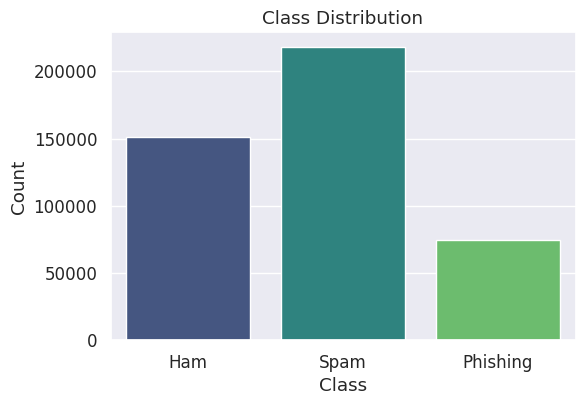

In [145]:
#class distribution
plt.figure(figsize=(6,4))
sns.countplot(x="label",data=df,palette="viridis")
plt.title("Class Distribution")
plt.xticks([0,1,2],["Ham","Spam","Phishing"])
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [146]:
#length of the text as a new column
df["message_length"]=df["text"].apply(len)
df.head()

,label,text,message_length
0,0,annual physical scheduled 5 jun 2025 1015 loca...,58
1,0,please save e mail records dear craig congratu...,1273
2,1,need urgent assistance donald williams esq 60 ...,1866
3,2,megasize unit megadlk huge advancement mens he...,244
4,0,original message rodenburg eric enron sent mon...,336


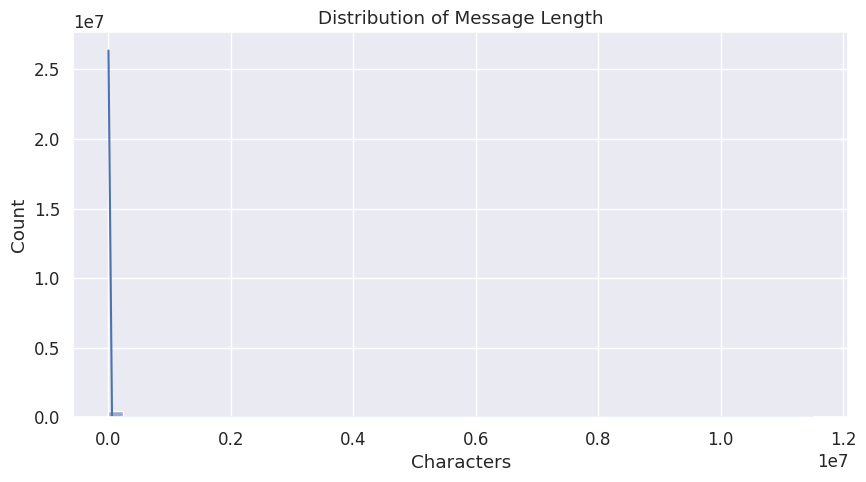

In [147]:
#distribution of teh text or message
plt.figure(figsize=(10,5))
sns.histplot(df["message_length"],bins=50,kde=True)
plt.title("Distribution of Message Length")
plt.xlabel("Characters")
plt.show()

In [148]:
#summary of the message lengtth
df["message_length"].describe()

,message_length
count,4.440340e+05
mean,7.027155e+02
std,1.837712e+04
min,6.000000e+00
25%,6.200000e+01
50%,7.900000e+01
75%,5.160000e+02
max,1.151031e+07


In [149]:
# finding the top 10 lengthiest comment
df.nlargest(10,"message_length")[["label","message_length","text"]]

,label,message_length,text
271077,0,11510306,bodylabel 0subject great parttime summer job d...
124150,0,2712980,begun work dmdx problem getting following item...
188535,0,1097012,dr gilfoyle right repartitioning question need...
228698,0,1031430,hi sorry raping french language last message w...
177407,0,993969,telecom digest wed escapenumber nov escapenumb...
364333,0,894004,pdf list service provided pdfzone com http www...
166348,1,864685,email administrator securityupdatewebmailcom s...
382109,0,863747,telecom digest thu escapenumber jan escapenumb...
290960,0,738475,deal unicode line separator would want use opp...
350645,0,605194,list failed recipients requested action taken ...


In [150]:
#calculating the message length
df["message_length"]=df["text"].astype(str).apply(len)

In [151]:
#selectiing the rows which has the lengtth less than 1000
df=df[df["message_length"]<=1000]

In [152]:
#avoiding the very shoretr messages
df=df[df["message_length"]>=5]

In [153]:
#idex reset and final dataset dimensions
df.reset_index(drop=True,inplace=True)
print(df.shape)

(374585, 3)


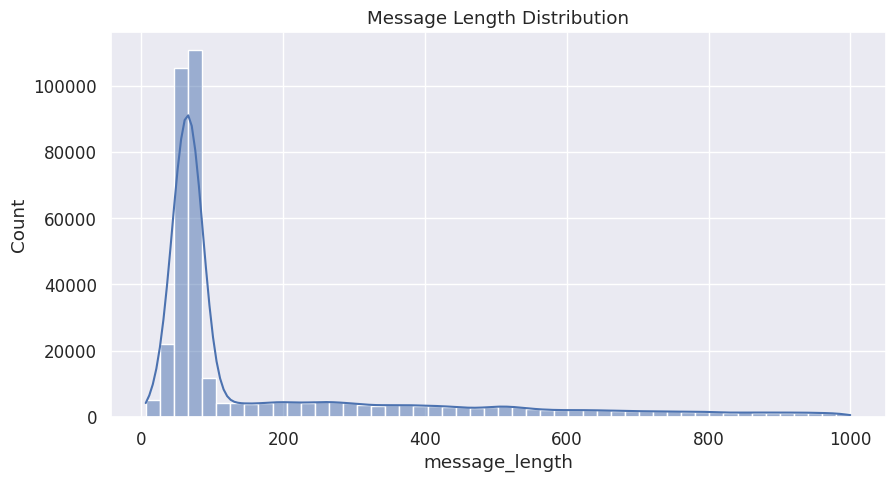

In [154]:
#distribution of teh text or message
plt.figure(figsize=(10,5))
sns.histplot(df["message_length"],bins=50,kde=True)
plt.title("Message Length Distribution")
plt.show()

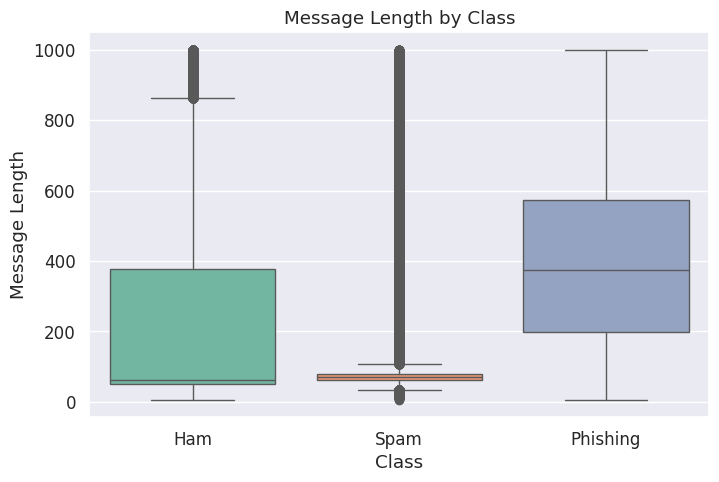

In [155]:
#message length distribution across ham, spam, and phishing classes using box plot
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="label",y="message_length",palette="Set2")
plt.xticks([0,1,2],["Ham","Spam","Phishing"])
plt.title("Message Length by Class")
plt.xlabel("Class")
plt.ylabel("Message Length")
plt.show()

In [156]:
#statistics of message lengths down by class
df.groupby("label")["message_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,114876.0,232.446595,268.542042,6.0,52.0,62.0,376.0,1000.0
1,208631.0,105.888176,122.081997,6.0,62.0,71.0,80.0,1000.0
2,51078.0,404.566173,252.962313,6.0,198.0,374.0,572.0,1000.0


In [157]:
#text Cleaning Function
def clean_text(text):

    #converting to lowercase
    text=text.lower()
    #removeing URLs
    text=re.sub(r"http\S+|www\S+","",text)
    #removeing email addresses
    text=re.sub(r"\S+@\S+","",text)
    #removeing phone numbers
    text=re.sub(r"\d{7,}","",text)
    #removeing punctuation
    text=text.translate(str.maketrans("","",string.punctuation))
    #removeing extra spaces
    text=re.sub(r"\s+"," ",text).strip()
    return text

In [158]:
#apply Cleaning
df["clean_text"]=df["text"].apply(clean_text)
df.head()

,label,text,message_length,clean_text
0,0,annual physical scheduled 5 jun 2025 1015 loca...,58,annual physical scheduled 5 jun 2025 1015 loca...
1,2,megasize unit megadlk huge advancement mens he...,244,megasize unit megadlk huge advancement mens he...
2,0,original message rodenburg eric enron sent mon...,336,original message rodenburg eric enron sent mon...
3,0,wondered laptops found work well dmdx inspiron...,503,wondered laptops found work well dmdx inspiron...
4,0,sbi account xxxx1234 credited rs 25500 17 jul ...,50,sbi account xxxx1234 credited rs 25500 17 jul ...


In [159]:
#compare original vs cleaned text
df[["text","clean_text"]].head()

,text,clean_text
0,annual physical scheduled 5 jun 2025 1015 loca...,annual physical scheduled 5 jun 2025 1015 loca...
1,megasize unit megadlk huge advancement mens he...,megasize unit megadlk huge advancement mens he...
2,original message rodenburg eric enron sent mon...,original message rodenburg eric enron sent mon...
3,wondered laptops found work well dmdx inspiron...,wondered laptops found work well dmdx inspiron...
4,sbi account xxxx1234 credited rs 25500 17 jul ...,sbi account xxxx1234 credited rs 25500 17 jul ...


In [160]:
#balanced sampling
sample_size=100000
samples_per_class=sample_size//3
df_sample=(df.groupby("label", group_keys=False).apply(lambda x: x.sample(n=min(len(x), samples_per_class),
          random_state=42)).reset_index(drop=True))
print(df_sample.shape)

(99999, 4)


In [161]:
#class distribution in the sampled dataset
print(df_sample["label"].value_counts())

label
0    33333
1    33333
2    33333
Name: count, dtype: int64


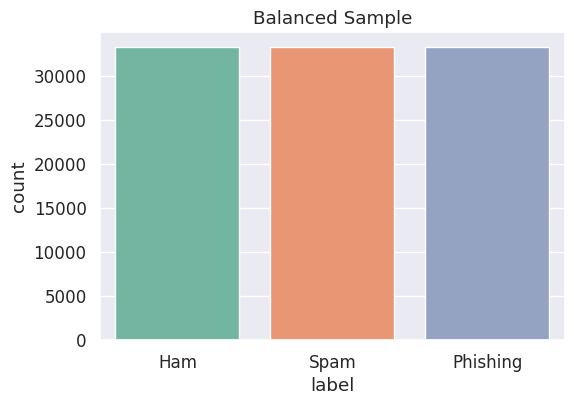

In [162]:
#balanced distribution
plt.figure(figsize=(6,4))
sns.countplot(x="label",data=df_sample,palette="Set2")
plt.xticks([0,1,2],["Ham","Spam","Phishing"])
plt.title("Balanced Sample")
plt.show()

In [163]:
#train test split
from sklearn.model_selection import train_test_split

df_sample, _=train_test_split(df,train_size=100000,stratify=df["label"],random_state=42)
print(df_sample.shape)

(100000, 4)


In [164]:
#train test split
train_texts,test_texts,train_labels,test_labels=train_test_split(
    df_sample["clean_text"],
    df_sample["label"],
    test_size=0.2,
    stratify=df_sample["label"],
    random_state=42)

In [165]:
print("Training Samples:",len(train_texts))
print("Testing Samples :",len(test_texts))

print("\nTraining Label Distribution:")
print(train_labels.value_counts())

print("\nTesting Label Distribution:")
print(test_labels.value_counts())

Training Samples: 80000
Testing Samples : 20000

Training Label Distribution:
label
1    44558
0    24533
2    10909
Name: count, dtype: int64

Testing Label Distribution:
label
1    11139
0     6134
2     2727
Name: count, dtype: int64


In [166]:
# test labels count
print(test_labels.value_counts())

label
1    11139
0     6134
2     2727
Name: count, dtype: int64


In [167]:
#loading the pre-trained uncased BERT tokenizer
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [168]:
#Tokenize and encode train, test text sequences into padded, truncated token ID vectors of length (128) for BERT
train_encodings=tokenizer(
    train_texts.tolist(),
    truncation=True,
    padding="max_length",
    max_length=128)

test_encodings=tokenizer(
    test_texts.tolist(),
    truncation=True,
    padding="max_length",
    max_length=128)

In [169]:
import torch
#custom PyTorch dataset class to structure BERT encodings and labels for PyTorch dataLoader batching
class SMSDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings=encodings
        self.labels=labels.tolist()

    def __getitem__(self, idx):
        item={key: torch.tensor(val[idx])for key, val in self.encodings.items()}
        item["labels"]=torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [170]:
#PyTorch dataset objects for train and test splits
train_dataset=SMSDataset(train_encodings, train_labels)
test_dataset=SMSDataset(test_encodings, test_labels)

In [171]:
from torch.utils.data import DataLoader

BATCH_SIZE=64
#creating training DataLoader with shuffling for gradient optimization and faster GPU settings
train_loader=DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True)
#creating test DataLoader without shuffling
test_loader=DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True)

In [172]:
#printing the outputs
print("Training Samples :",len(train_dataset))
print("Testing Samples  :",len(test_dataset))

print("Training Batches :",len(train_loader))
print("Testing Batches  :",len(test_loader))

Training Samples : 80000
Testing Samples  : 20000
Training Batches : 1250
Testing Batches  : 313


In [173]:
from transformers import BertForSequenceClassification
#loading the pre-trained uncased BERT with a custom linear classification head for 3 target classes
model=BertForSequenceClassification.from_pretrained("bert-base-uncased",num_labels=3)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [174]:
import torch
#set computation device GPU if available, else CPU
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:",device)
model.to(device)

Using device: cuda


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [175]:
from torch.optim import AdamW
#initializing the optimizer with a low learning rate
optimizer=AdamW(model.parameters(),lr=2e-5)

In [176]:
#importing tqdm for training progress bars and scikit-learn metrics for evaluation
from tqdm import tqdm
from sklearn.metrics import(accuracy_score,precision_recall_fscore_support)

In [177]:
#to store loss and accuracy
train_losses=[]
eval_losses=[]

train_accs=[]
eval_accs=[]

In [178]:
epochs=3
for epoch in range(epochs):

    #training
    model.train()
    total_train_loss=0
    train_predictions=[]
    train_true=[]
    loop=tqdm(train_loader,desc=f"Epoch {epoch+1}")

    for batch in loop:
        optimizer.zero_grad()
        input_ids=batch["input_ids"].to(device)
        attention_mask=batch["attention_mask"].to(device)
        labels=batch["labels"].to(device)

        outputs=model(input_ids=input_ids,attention_mask=attention_mask,labels=labels)
        loss=outputs.loss
        logits=outputs.logits
        total_train_loss += loss.item()
        loss.backward()
        optimizer.step()
        preds=torch.argmax(logits, dim=1)
        train_predictions.extend(preds.cpu().numpy())
        train_true.extend(labels.cpu().numpy())
        loop.set_postfix(loss=loss.item())

    avg_train_loss=total_train_loss / len(train_loader)
    train_accuracy=accuracy_score(train_true, train_predictions)

    train_losses.append(avg_train_loss)
    train_accs.append(train_accuracy)
    #validation
    model.eval()

    total_eval_loss=0
    eval_predictions=[]
    eval_true=[]

    with torch.no_grad():
        for batch in test_loader:

            input_ids=batch["input_ids"].to(device)
            attention_mask=batch["attention_mask"].to(device)
            labels=batch["labels"].to(device)

            outputs=model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels)

            loss=outputs.loss
            logits=outputs.logits
            total_eval_loss += loss.item()
            preds=torch.argmax(logits, dim=1)
            eval_predictions.extend(preds.cpu().numpy())
            eval_true.extend(labels.cpu().numpy())

    avg_eval_loss=total_eval_loss / len(test_loader)
    eval_accuracy=accuracy_score(eval_true, eval_predictions)

    eval_losses.append(avg_eval_loss)
    eval_accs.append(eval_accuracy)

Epoch 3: 100%|██████████| 1250/1250 [05:50<00:00,  3.57it/s, loss=0.0148]


In [179]:
print(f"\nEpoch {epoch+1}/{epochs}")

print(f"Train Loss     : {avg_train_loss:.4f}")
print(f"Train Accuracy : {train_accuracy:.4f}")

print(f"Validation Loss     : {avg_eval_loss:.4f}")
print(f"Validation Accuracy : {eval_accuracy:.4f}")


Epoch 3/3
Train Loss     : 0.0314
Train Accuracy : 0.9868
Validation Loss     : 0.0560
Validation Accuracy : 0.9786


In [180]:
#printing the outputs
print(train_losses)
print(eval_losses)

print(train_accs)
print(eval_accs)

[0.11560086696408689, 0.04982716157147661, 0.031438753001764415]
[0.060769104534170976, 0.054367235815226914, 0.055982341888801794]
[0.951025, 0.97815, 0.986775]
[0.9731, 0.97695, 0.9786]


In [181]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix)
# switching model to evaluation mode (disables dropout and batch normalization updates)
model.eval()

predictions=[]
true_labels=[]
# disabling gradient calculation to save memory and accelerate inference during testing
with torch.no_grad():
    for batch in test_loader:

        input_ids=batch["input_ids"].to(device)
        attention_mask=batch["attention_mask"].to(device)
        labels=batch["labels"].to(device)
        # performing forward pass
        outputs=model(input_ids=input_ids,attention_mask=attention_mask)
        # extracting predictions
        logits=outputs.logits
        preds=torch.argmax(logits, dim=1)
        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

In [182]:
# performance metrics
accuracy=accuracy_score(true_labels, predictions)
precision=precision_score(true_labels,predictions,average="weighted")
recall=recall_score(true_labels,predictions,average="weighted")
f1=f1_score(true_labels,predictions,average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9786
Precision: 0.9788
Recall   : 0.9786
F1 Score : 0.9787


In [183]:
# classification report
print(classification_report(true_labels,predictions,target_names=["Ham","Spam","Phishing"]))

              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99      6134
        Spam       0.99      0.98      0.99     11139
    Phishing       0.92      0.94      0.93      2727

    accuracy                           0.98     20000
   macro avg       0.96      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000



In [184]:
# confusion matrix
cm = confusion_matrix(true_labels, predictions)
print(cm)

[[ 6070     6    58]
 [   12 10952   175]
 [   70   107  2550]]


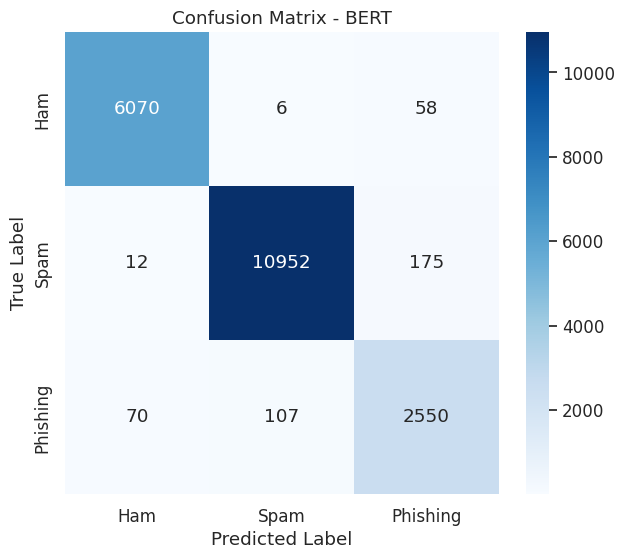

In [185]:
# ploting the confusion matrix
plt.figure(figsize=(7,6))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Ham","Spam","Phishing"],yticklabels=["Ham","Spam","Phishing"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - BERT")
plt.show()

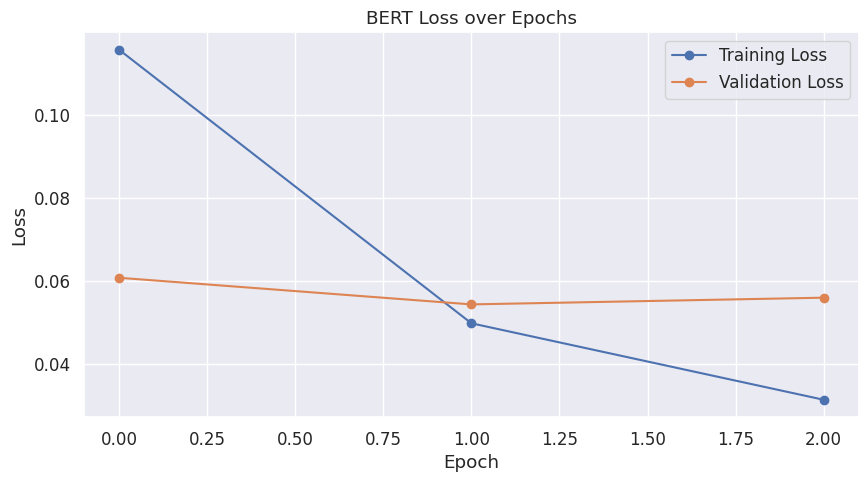

In [186]:
# loss over epochs plot
plt.figure(figsize=(10,5))
plt.plot(train_losses, marker="o", label="Training Loss")
plt.plot(eval_losses, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BERT Loss over Epochs")
plt.legend()
plt.show()

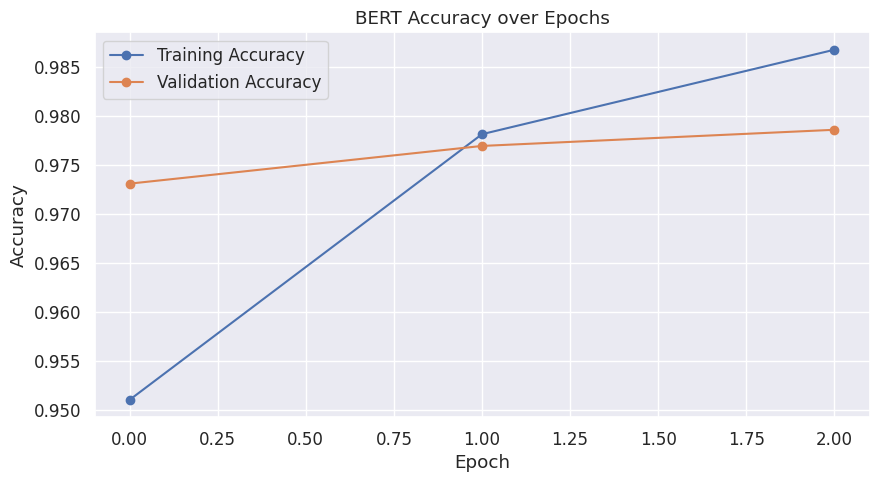

In [187]:
# accuracy over epochs plot
plt.figure(figsize=(10,5))
plt.plot(train_accs, marker="o", label="Training Accuracy")
plt.plot(eval_accs, marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BERT Accuracy over Epochs")
plt.legend()
plt.show()

In [188]:
def predict_message(text_message, model, tokenizer, device, max_length=128):
    # setting model to evaluation mode for disabling dropout
    model.eval()

    # mapping label indices back to text categories
    label_map = {0: "Ham", 1: "Spam", 2: "Phishing"}

    # tokenizing and encoding input sentence for model input
    encoded_inputs = tokenizer(
        text_message,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="pt")

    # moving input tensors to active computation device (GPU/CPU)
    input_ids = encoded_inputs["input_ids"].to(device)
    attention_mask = encoded_inputs["attention_mask"].to(device)

    # running inference without computing gradients
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        # computing predicted class index and class probabilities
        predicted_class_idx = torch.argmax(logits, dim=1).item()
        probabilities = torch.softmax(logits, dim=1).squeeze().cpu().numpy()

    predicted_label = label_map[predicted_class_idx]
    confidence = probabilities[predicted_class_idx] * 100

    # Printing classification result with confidence score
    print(f"\nMessage   : '{text_message}'")
    print(f"Prediction: {predicted_label} ({confidence:.2f}% confidence)")


# prompting user for text entry
while True:
    user_input = input("\nEnter a message to classify (or type 'exit' to quit): ")
    if user_input.lower() == 'exit':
        print("Exiting prediction loop.")
        break

    # running prediction on user-entered text
    predict_message(user_input, model, tokenizer, device)


Enter a message to classify (or type 'exit' to quit): Your Netflix verification code is 482019. It will expire in 10 minutes. Do not share this code.

Message   : 'Your Netflix verification code is 482019. It will expire in 10 minutes. Do not share this code.'
Prediction: Spam (96.69% confidence)

Enter a message to classify (or type 'exit' to quit): Your Netflix verification code is 482019

Message   : 'Your Netflix verification code is 482019'
Prediction: Spam (97.63% confidence)

Enter a message to classify (or type 'exit' to quit): Hi Sarah, this is a reminder from Smile Dental. You have an appointment tomorrow, Tuesday 4 August, at 10:15 AM

Message   : 'Hi Sarah, this is a reminder from Smile Dental. You have an appointment tomorrow, Tuesday 4 August, at 10:15 AM'
Prediction: Ham (99.94% confidence)

Enter a message to classify (or type 'exit' to quit): Barclays: A new payee named MR J SMITH was successfully added to your mobile banking app. If you did not authorize this, cancel

##**LR and NB**

In [189]:
# necessary libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix)

In [190]:
# initialising TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words="english")

In [191]:
# fitting TF-IDF vocabulary on training texts and transforming both train and test splits into sparse feature matrices
X_train_tfidf=tfidf.fit_transform(train_texts)
X_test_tfidf=tfidf.transform(test_texts)

print("Training TF-IDF shape:",X_train_tfidf.shape)
print("Testing TF-IDF shape:",X_test_tfidf.shape)

Training TF-IDF shape: (80000, 10000)
Testing TF-IDF shape: (20000, 10000)


In [192]:
# initialising Logistic Regression
logistic_model=LogisticRegression(max_iter=1000,random_state=42)
logistic_model.fit(X_train_tfidf,train_labels)

LogisticRegression(max_iter=1000, random_state=42)

In [193]:
# predictions on test set
lr_predictions=logistic_model.predict(X_test_tfidf)

In [194]:
# evealuation metrics
lr_accuracy=accuracy_score(test_labels,lr_predictions)
lr_precision =precision_score(test_labels,lr_predictions,average="weighted")
lr_recall =recall_score(test_labels,lr_predictions,average="weighted")
lr_f1 = f1_score(test_labels,lr_predictions,average="weighted")

print("Logistic Regression Results")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Logistic Regression Results
Accuracy : 0.95875
Precision: 0.9591141050705788
Recall   : 0.95875
F1 Score : 0.9588868681674932


In [195]:
# classifiaction report
print(classification_report(test_labels,lr_predictions,target_names=["Ham","Spam","Phishing"]))

              precision    recall  f1-score   support

         Ham       0.97      0.98      0.97      6134
        Spam       0.98      0.97      0.98     11139
    Phishing       0.85      0.87      0.86      2727

    accuracy                           0.96     20000
   macro avg       0.93      0.94      0.94     20000
weighted avg       0.96      0.96      0.96     20000



##**Naïve Bayes**

In [196]:
# initialising Multinomial Naïve Bayes classifier and fitting model parameters
nb_model=MultinomialNB()
nb_model.fit(X_train_tfidf,train_labels)

MultinomialNB()

In [197]:
# predictions on test set
nb_predictions=nb_model.predict(X_test_tfidf)

In [198]:
# evaluation metrices
nb_accuracy =accuracy_score(test_labels,nb_predictions)
nb_precision = precision_score(test_labels,nb_predictions,average="weighted")
nb_recall = recall_score(test_labels,nb_predictions,average="weighted")
nb_f1 =f1_score(test_labels,nb_predictions,average="weighted")


print("Naïve Bayes Results")
print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)

Naïve Bayes Results
Accuracy : 0.9439
Precision: 0.9520546185456442
Recall   : 0.9439
F1 Score : 0.9461589093356219


##**Comparision**

In [199]:
# metrices comparision
results = pd.DataFrame({
"Model": ["Naive Bayes","Logistic Regression","BERT"],
"Accuracy": [nb_accuracy,lr_accuracy,accuracy],
"Precision": [nb_precision,lr_precision,precision],
"Recall": [nb_recall,lr_recall,recall],
"F1-score": [nb_f1,lr_f1,f1]})

print(results)

                 Model  Accuracy  Precision   Recall  F1-score
0          Naive Bayes   0.94390   0.952055  0.94390  0.946159
1  Logistic Regression   0.95875   0.959114  0.95875  0.958887
2                 BERT   0.97860   0.978809  0.97860  0.978685


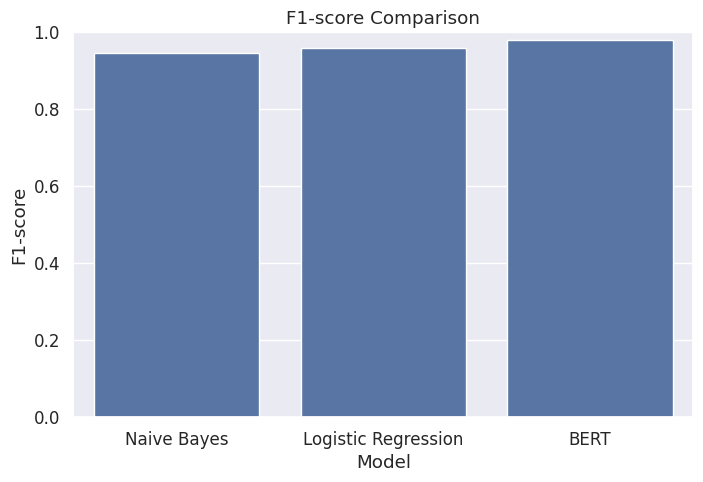

In [200]:
# plot comparing the f1 score of three model
plt.figure(figsize=(8,5))
sns.barplot(data=results,x="Model",y="F1-score")
plt.title("F1-score Comparison")
plt.ylim(0,1)
plt.show()